  customer_id  age occupation_status  years_employed  annual_income  \
0  CUST100000   40          Employed            17.2          25579   
1  CUST100001   33          Employed             7.3          43087   
2  CUST100002   42           Student             1.1          20840   
3  CUST100003   53           Student             0.5          29147   
4  CUST100004   32          Employed            12.5          63657   

   credit_score  credit_history_years  savings_assets  current_debt  \
0           692                   5.3             895         10820   
1           627                   3.5             169         16550   
2           689                   8.4              17          7852   
3           692                   9.8            1480         11603   
4           630                   7.2             209         12424   

   defaults_on_file  delinquencies_last_2yrs  derogatory_marks   product_type  \
0                 0                        0                 0   

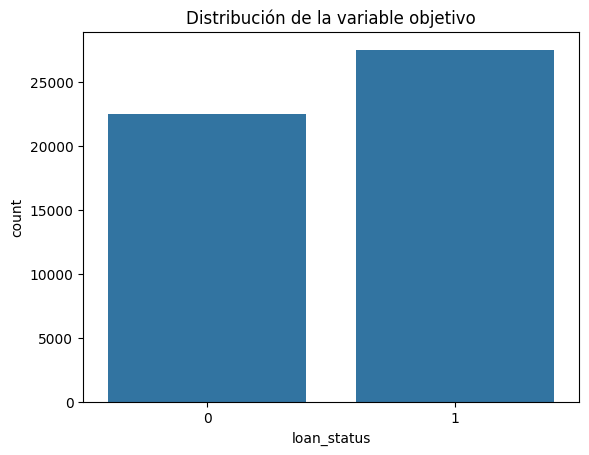

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


dataset_path = 'Loan_approval_data_2025.csv'
df = pd.read_csv(dataset_path)


print(df.head())


print(df.info())


print(df.describe())

#Compruebo valores nulos
print(df.isnull().sum())

# Verifico la distribución de la variable objetivo 'loan_status'
sns.countplot(x='loan_status', data=df)
plt.title('Distribución de la variable objetivo')
plt.show()


In [3]:
# === PREPROCESAMIENTO DE DATOS ===

# 1. Verificar y manejar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

# 2. Eliminar columnas irrelevantes (customer_id no aporta al modelo)
df_processed = df.drop('customer_id', axis=1)

# 3. Separar variables numéricas y categóricas
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()

print(f"\nVariables numéricas: {numeric_cols}")
print(f"Variables categóricas: {categorical_cols}")

# 4. Codificación One-Hot para variables categóricas
df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

print(f"\nForma original: {df_processed.shape}")
print(f"Forma después de encoding: {df_encoded.shape}")

# 5. Verificar balance de clases en la variable objetivo
print("\nDistribución de loan_status:")
print(df_encoded['loan_status'].value_counts(normalize=True))

# 6. Separar features (X) y target (y)
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")


Valores nulos por columna:
customer_id                0
age                        0
occupation_status          0
years_employed             0
annual_income              0
credit_score               0
credit_history_years       0
savings_assets             0
current_debt               0
defaults_on_file           0
delinquencies_last_2yrs    0
derogatory_marks           0
product_type               0
loan_intent                0
loan_amount                0
interest_rate              0
debt_to_income_ratio       0
loan_to_income_ratio       0
payment_to_income_ratio    0
loan_status                0
dtype: int64

Variables numéricas: ['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs', 'derogatory_marks', 'loan_amount', 'interest_rate', 'debt_to_income_ratio', 'loan_to_income_ratio', 'payment_to_income_ratio', 'loan_status']
Variables categóricas: ['occupation_status', 'produc

In [4]:
# === DIVISIÓN DE DATOS Y MODELADO BÁSICO ===
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Dividir datos (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, {y_train.value_counts(normalize=True)}")
print(f"Test: {X_test.shape}, {y_test.value_counts(normalize=True)}")

# 2. Modelos a comparar
models = {
    'Dummy (Baseline)': DummyClassifier(strategy='most_frequent'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
}

# 3. Entrenar y evaluar
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"\n{name}: {accuracy:.3f}")

print("\nResultados:")
for name, acc in results.items():
    print(f"{name}: {acc:.3f}")


Train: (37500, 24), loan_status
1    0.550453
0    0.449547
Name: proportion, dtype: float64
Test: (12500, 24), loan_status
1    0.55048
0    0.44952
Name: proportion, dtype: float64

Dummy (Baseline): 0.550

Decision Tree: 0.850

Random Forest: 0.866

Resultados:
Dummy (Baseline): 0.550
Decision Tree: 0.850
Random Forest: 0.866


=== CLASIFICATION REPORT (Random Forest) ===
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      5619
           1       0.85      0.92      0.88      6881

    accuracy                           0.87     12500
   macro avg       0.87      0.86      0.86     12500
weighted avg       0.87      0.87      0.87     12500



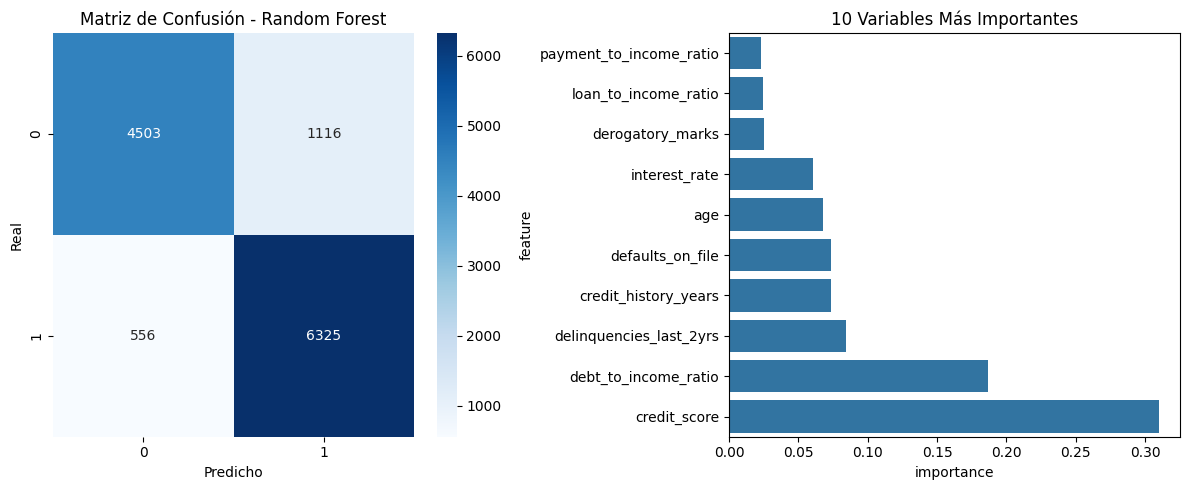


=== TOP 10 VARIABLES MÁS IMPORTANTES ===
                    feature  importance
14  payment_to_income_ratio    0.023186
13     loan_to_income_ratio    0.024774
9          derogatory_marks    0.025209
11            interest_rate    0.060357
0                       age    0.067894
7          defaults_on_file    0.073375
4      credit_history_years    0.073456
8   delinquencies_last_2yrs    0.084622
12     debt_to_income_ratio    0.187019
3              credit_score    0.309652


In [5]:
# === EVALUACIÓN DETALLADA Y VISUALIZACIONES ===
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# 1. Métricas detalladas del mejor modelo (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== CLASIFICATION REPORT (Random Forest) ===")
print(classification_report(y_test, y_pred_rf))

# 2. Matriz de confusión
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.ylabel('Real')
plt.xlabel('Predicho')

# 3. Importancia de variables
plt.subplot(1, 2, 2)
importances = rf_model.feature_importances_
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=True).tail(10)

sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('10 Variables Más Importantes')
plt.tight_layout()
plt.show()

# 4. Top 10 variables más importantes
print("\n=== TOP 10 VARIABLES MÁS IMPORTANTES ===")
print(feature_importance.tail(10))
